In [ ]:
from kymotools.detect import Detector
from lumicks import pylake

import kymotools.io as kio
import math
import numpy as np
import os

/Users/sc13967/Documents/Programming/Python/ctrap-analysis/.pixi/envs/n2v/lib/python3.10/site-packages/kymotools/io.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Parameters
path = "./examples/input/"
channel = 0

In [ ]:
# Step fitting
def fit_steps(tracks, image,WinSize=300,LMthresh=300,half_x_w=1,half_t_w=1):
    for track in tracks.values():
        track.measure_intensity(image,half_x_w=half_x_w,)
        # track.apply_temporal_filter()
        find_change_points(track,WinSize=WinSize,LMthresh=LMthresh)

# The following methods are translated from the BaLM MATLAB tool, which itself was based on the publication Watkins and Yang, J. Phys. Chem. B, Vol. 109, No. 1
def find_change_points(track, WinSize=300, LMthresh=300):
    time = np.array(list(track.intensity.keys()))
    data = np.array(list(track.intensity.values()))

    nData = len(data)
    ChangePnt = np.zeros(data.shape)
    ChangePnt[0] = 1
    ChangePnt[-1] = 1

    crntChange = 0
    nxtChange = nData
    nCPnt = 1

    while crntChange < nData-1:
        if (nxtChange-crntChange) > WinSize:
            datain=data[(crntChange+1):nxtChange]
            (Cpt, LM) = _LRtest(datain)
            
            if LM>LMthresh:
                ChangePnt[crntChange+Cpt]=1
                nCPnt=nCPnt+1
                nxtChange=crntChange+Cpt
            else:
                crntChange=nxtChange
                if crntChange<nData-1:
                    nxtChange=nxtChange+1
                    while ChangePnt[nxtChange]==0:
                        nxtChange=nxtChange+1

        else:
            crntChange=nxtChange
            if crntChange<nData-1:
                nxtChange=nxtChange+1
                while ChangePnt[nxtChange]==0:
                    nxtChange=nxtChange+1

    tCPnt = np.where(ChangePnt != 0)[0]
    
    track.step_trace={}
    for j in range(nCPnt):
        Ilevel=sum(data[tCPnt[j]+1:tCPnt[j+1]])/(tCPnt[j+1]-tCPnt[j])
        for i in range(tCPnt[j]+1,tCPnt[j+1]+1):
            track.step_trace[time[i]] = Ilevel
    track.step_trace[time[0]] = track.step_trace[time[1]]
    track.step_trace = dict(sorted(track.step_trace.items()))
    
    # Remove "step" at 0 and the end, then convert indices to timepoints
    tCPnt = tCPnt[np.where(tCPnt!=0)]
    tCPnt = tCPnt[np.where(tCPnt!=time[-1])]
    tCPnt = time[tCPnt]
    track.steps = tCPnt

def _LRtest(datain):
        nd=len(datain)
        L = np.zeros(nd)

        SS = sum(datain[:])
        S = np.cumsum(datain)

        LM=0
        Cpt=0
        for k in range(nd):
            if S[k] > 0 and SS-S[k] > 0:
                L[k]=S[k]*math.log(S[k]/(k+1))+(SS-S[k])*math.log((SS-S[k])/(nd-(k+1)))-SS*math.log(SS/nd)
                if LM<L[k]:
                    LM=L[k]
                    Cpt=k

        return (Cpt,LM)

# Function to process single image
def process_image(image,channel,output_name):
    # Initialising Detector
    detector = Detector(half_t_w=0, peak_det_thresh = 5, n_max=12, a_lb=0.5, c_lb=1.2,c_ub=5, c_def=4, min_track_length = 10, track_heritage_weight=18, max_dist=8, max_frame_gap=10, starting_window=10)

    # Detect peaks and track
    tracks = detector.detect(image)

    # Saving files
    kio.save_overlay(tracks,image,output_name+"_overlay")
    
    # Measuring intensity (raw)
    for track in tracks.values():
        track.measure_intensity(image)

    # Fitting steps to trace
    fit_steps(tracks,image,WinSize=100,LMthresh=100)

    # Saving files
    kio.write_track_data(tracks,output_name+"_traces")
    kio.write_intensity_traces(tracks,output_name+"_steps")
    kio.save_plots(tracks,output_name+"_traces")
    kio.write_change_points(tracks,output_name+'_steps_summary')
    kio.save_overlay(tracks,image,output_name+"_overlay")

Processing:  20220615-111125 Kymograph 3_kymograph0


100%|████████████████████████████████████████| 339/339 [00:01<00:00, 332.78it/s]
/Users/sc13967/Documents/Programming/Python/ctrap-analysis/.pixi/envs/n2v/lib/python3.10/site-packages/kymotools/kymo.py:75: RuntimeWarning: Mean of empty slice.
  self.intensity[t] = image[x-half_x_w:x+half_x_w,t].mean()
/Users/sc13967/Documents/Programming/Python/ctrap-analysis/.pixi/envs/n2v/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


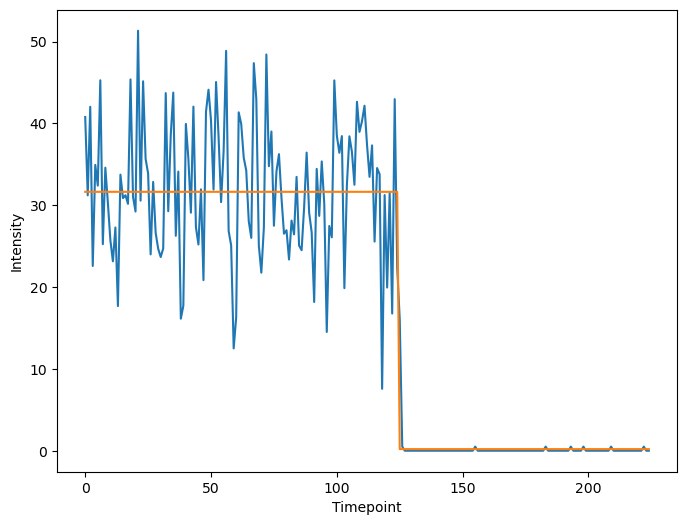

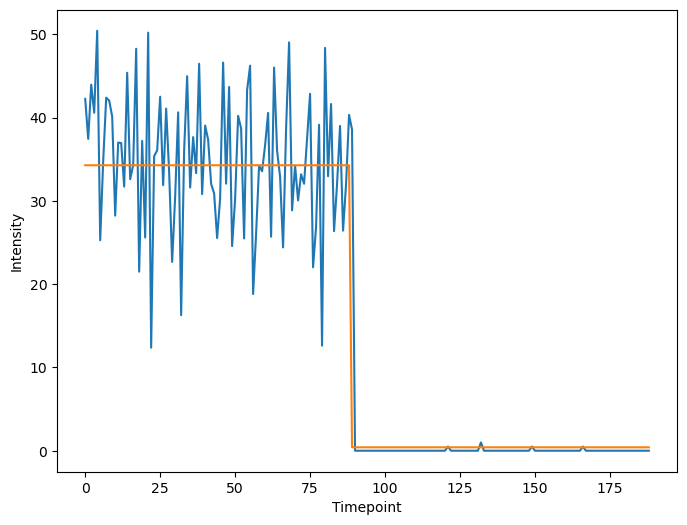

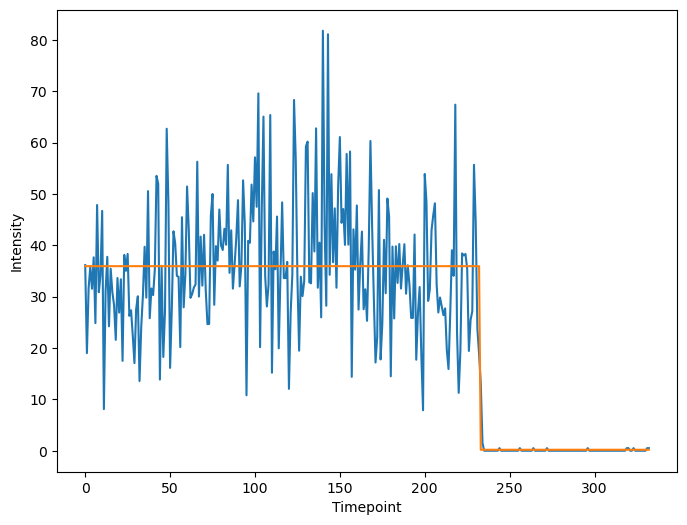

In [4]:
# Loading image and calculating paths
for f in os.listdir(path):
    name = os.path.basename(os.path.splitext(f)[0])
    print("Processing: ",name)
    if os.path.splitext(f)[1] == ".tif":
        image = kio.read_image(path+f,channel,x_range=None)
        output_name = path+name+'_C'+str(channel)
        process_image(image, channel, output_name)
    elif os.path.splitext(f)[1] == ".h5" or os.path.splitext(f)[1] == ".hdf5":
        file = pylake.File(path+f)
        for (idx,kymo) in enumerate(file.kymos.values()):
            image = kymo.get_image()[:,:,channel]
            output_name = path+name+'_C'+str(channel)+'_kymo'+str(idx+1)
            process_image(image, channel, output_name)        
    else:
        continue